  DATA CLEANING & VISUALIZATION PROJECT
  Retail Sales Dataset — 2023

[RAW] Shape      : (515, 9)
[RAW] Duplicates : 14
[RAW] Missing    :
sales           24
discount        20
customer_age    15
dtype: int64
[RAW] Neg sales  : 5

── Cleaning ──
  Duplicates removed : 14
  Outliers capped    : 15
  Final shape        : (501, 13)
  Remaining nulls    : 0

── Key Statistics ──
  Total Revenue  : ₹1,968,931
  Avg Order Value: ₹3,930
  Top Category   : Books
  Top Region     : North

✅  Dashboard saved → retail_dashboard.png
✅  Cleaned data  saved → cleaned_retail_data.csv

Done! 🎉


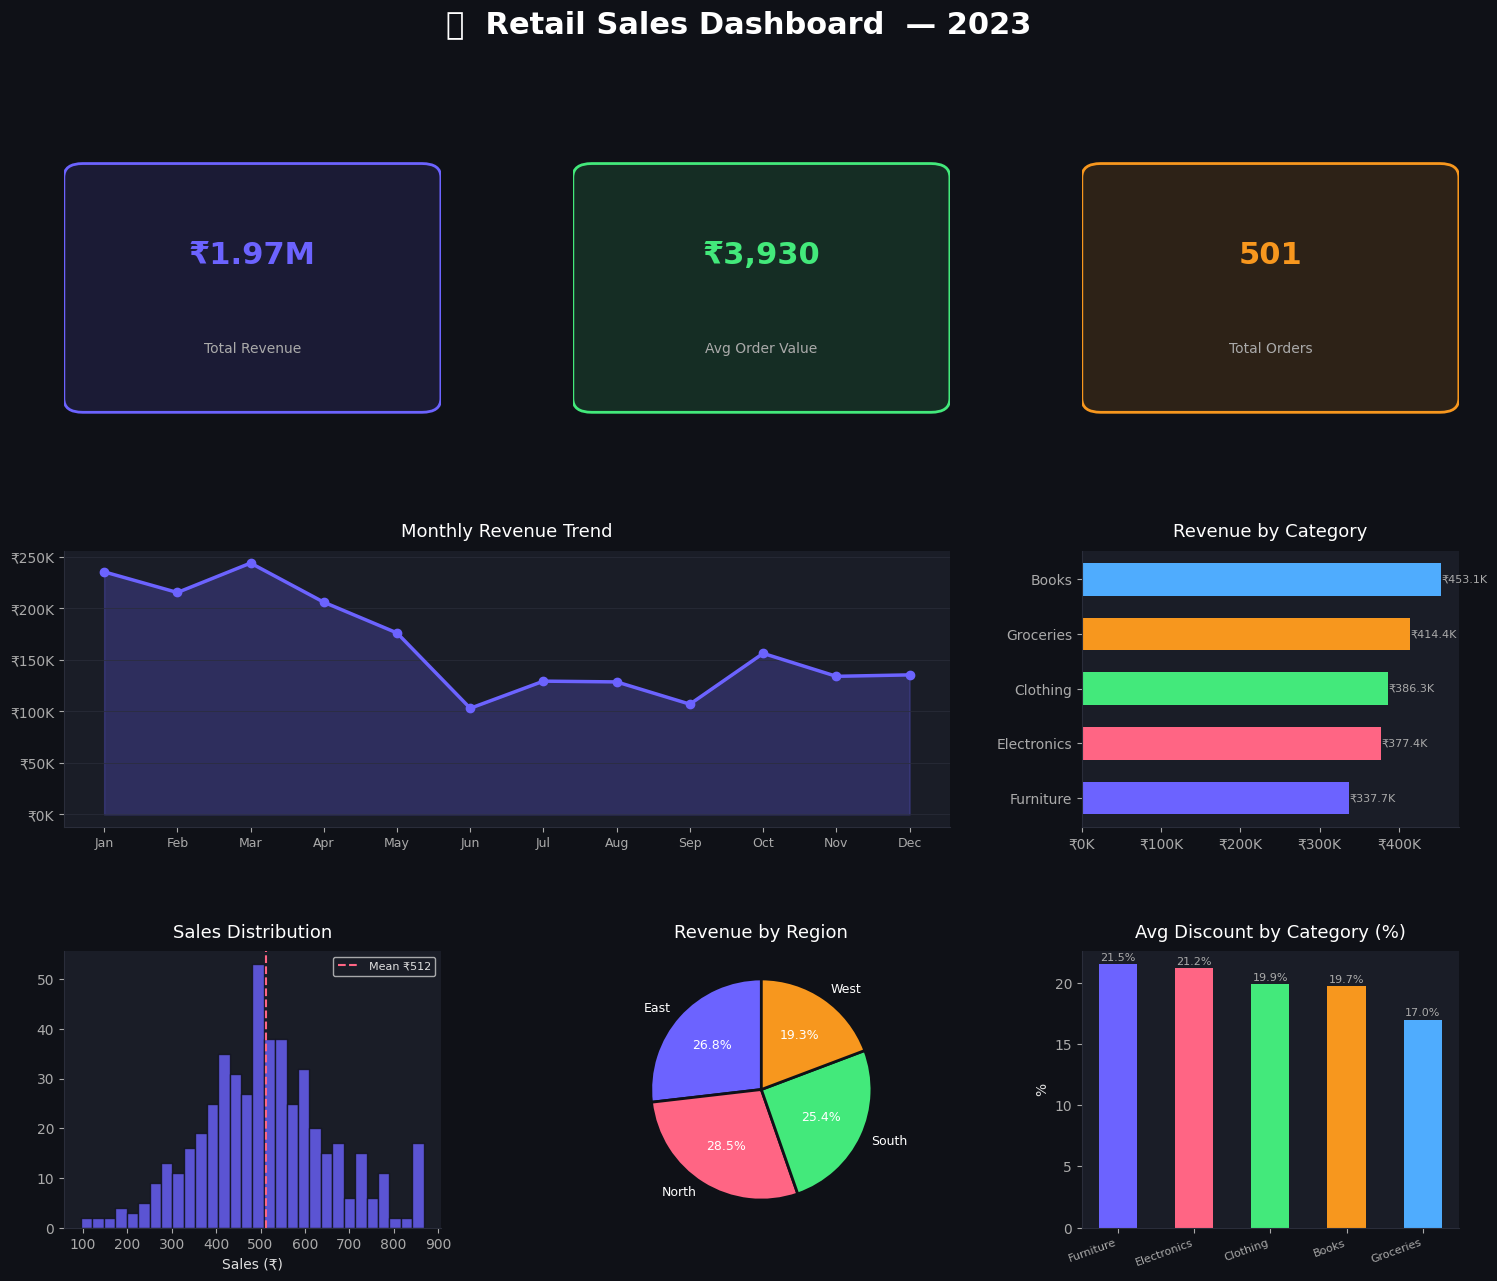

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────
# 1. GENERATE SAMPLE DATASET (Retail Sales)
# ─────────────────────────────────────────
np.random.seed(42)
n = 500

categories   = ['Electronics', 'Clothing', 'Groceries', 'Books', 'Furniture']
regions      = ['North', 'South', 'East', 'West']
payment_types= ['Credit Card', 'Cash', 'UPI', 'Debit Card']

data = {
    'order_id'    : range(1001, 1001 + n),
    'date'        : pd.date_range('2023-01-01', periods=n, freq='D')[:n],
    'category'    : np.random.choice(categories, n),
    'region'      : np.random.choice(regions, n),
    'sales'       : np.random.normal(500, 150, n).round(2),
    'quantity'    : np.random.randint(1, 20, n),
    'discount'    : np.random.uniform(0, 0.4, n).round(2),
    'payment_type': np.random.choice(payment_types, n),
    'customer_age': np.random.randint(18, 70, n),
}

df = pd.DataFrame(data)
# ── Inject imperfections ──────────────────
# Missing values
for col, pct in [('sales', 0.05), ('discount', 0.04), ('customer_age', 0.03)]:
    idx = np.random.choice(df.index, size=int(n * pct), replace=False)
    df.loc[idx, col] = np.nan

# Outliers
df.loc[np.random.choice(df.index, 10, replace=False), 'sales'] = np.random.uniform(3000, 5000, 10)

# Duplicates
dup_idx = np.random.choice(df.index, 15, replace=False)
df = pd.concat([df, df.loc[dup_idx]], ignore_index=True)

# Negative sales
df.loc[np.random.choice(df.index, 5, replace=False), 'sales'] = -abs(np.random.normal(100, 30, 5))

print("=" * 60)
print("  DATA CLEANING & VISUALIZATION PROJECT")
print("  Retail Sales Dataset — 2023")
print("=" * 60)

# ─────────────────────────────────────────
# 2. INITIAL INSPECTION
# ─────────────────────────────────────────
print(f"\n[RAW] Shape      : {df.shape}")
print(f"[RAW] Duplicates : {df.duplicated().sum()}")
print(f"[RAW] Missing    :\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"[RAW] Neg sales  : {(df['sales'] < 0).sum()}")
# ─────────────────────────────────────────
# 3. DATA CLEANING
# ─────────────────────────────────────────
print("\n── Cleaning ──")

# 3a. Remove duplicates
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"  Duplicates removed : {before - len(df)}")

# 3b. Fix negative sales
df.loc[df['sales'] < 0, 'sales'] = np.nan

# 3c. Impute missing values
df['sales']        = df['sales'].fillna(df.groupby('category')['sales'].transform('median'))
df['discount']     = df['discount'].fillna(df['discount'].median())
df['customer_age'] = df['customer_age'].fillna(df['customer_age'].median()).astype(int)

# 3d. Cap outliers (IQR method)
Q1, Q3 = df['sales'].quantile([0.25, 0.75])
IQR = Q3 - Q1
upper_cap = Q3 + 1.5 * IQR
outliers_capped = (df['sales'] > upper_cap).sum()
df['sales'] = df['sales'].clip(upper=upper_cap)
print(f"  Outliers capped    : {outliers_capped}")

# 3e. Feature engineering
df['revenue']   = (df['sales'] * df['quantity'] * (1 - df['discount'])).round(2)
df['month']     = df['date'].dt.month_name()
df['month_num'] = df['date'].dt.month
df['age_group'] = pd.cut(df['customer_age'], bins=[17,30,45,60,70],
                         labels=['18-30','31-45','46-60','61-70'])

print(f"  Final shape        : {df.shape}")
print(f"  Remaining nulls    : {df.isnull().sum().sum()}")
# ─────────────────────────────────────────
# 4. SUMMARY STATS
# ─────────────────────────────────────────
print("\n── Key Statistics ──")
total_rev = df['revenue'].sum()
avg_order = df['revenue'].mean()
top_cat   = df.groupby('category')['revenue'].sum().idxmax()
top_region= df.groupby('region')['revenue'].sum().idxmax()
print(f"  Total Revenue  : ₹{total_rev:,.0f}")
print(f"  Avg Order Value: ₹{avg_order:,.0f}")
print(f"  Top Category   : {top_cat}")
print(f"  Top Region     : {top_region}")

# ─────────────────────────────────────────
# 5. VISUALIZATION DASHBOARD
# ─────────────────────────────────────────
plt.rcParams.update({
    'font.family'     : 'DejaVu Sans',
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'figure.facecolor': '#0f1117',
    'axes.facecolor'  : '#1a1d27',
    'text.color'      : '#e0e0e0',
    'axes.labelcolor' : '#e0e0e0',
    'xtick.color'     : '#aaaaaa',
    'ytick.color'     : '#aaaaaa',
    'axes.edgecolor'  : '#2a2d3a',
    'grid.color'      : '#2a2d3a',
    'grid.linewidth'  : 0.5,
})

ACCENT  = '#6c63ff'
PALETTE = ['#6c63ff','#ff6584','#43e97b','#f7971e','#4facfe']

fig = plt.figure(figsize=(18, 14), facecolor='#0f1117')
fig.suptitle('🛒  Retail Sales Dashboard  — 2023',
             fontsize=22, fontweight='bold', color='white',
             y=0.98, x=0.5)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
# ── KPI Cards (top row) ──────────────────
kpis = [
    ("Total Revenue",    f"₹{total_rev/1e6:.2f}M", "#6c63ff"),
    ("Avg Order Value",  f"₹{avg_order:,.0f}",      "#43e97b"),
    ("Total Orders",     f"{len(df):,}",             "#f7971e"),
]
for i, (label, val, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor('#1a1d27')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis('off')
    rect = FancyBboxPatch((0.05,0.1), 0.9, 0.8,
                          boxstyle="round,pad=0.05",
                          facecolor=color+'22', edgecolor=color, linewidth=2)
    ax.add_patch(rect)
    ax.text(0.5, 0.62, val,  ha='center', va='center',
            fontsize=22, fontweight='bold', color=color)
    ax.text(0.5, 0.28, label, ha='center', va='center',
            fontsize=10, color='#aaaaaa')

# ── Monthly Revenue Trend ────────────────
ax1 = fig.add_subplot(gs[1, :2])
monthly = df.groupby('month_num')['revenue'].sum().reset_index()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
monthly['label'] = monthly['month_num'].apply(lambda x: month_labels[x-1])
ax1.fill_between(monthly['month_num'], monthly['revenue'],
                 alpha=0.25, color=ACCENT)
ax1.plot(monthly['month_num'], monthly['revenue'],
         color=ACCENT, linewidth=2.5, marker='o', markersize=6)
ax1.set_title('Monthly Revenue Trend', color='white', fontsize=13, pad=10)
ax1.set_xticks(monthly['month_num'])
ax1.set_xticklabels(monthly['label'], fontsize=9)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}K'))
ax1.grid(True, axis='y')
# ── Revenue by Category ──────────────────
ax2 = fig.add_subplot(gs[1, 2])
cat_rev = df.groupby('category')['revenue'].sum().sort_values()
bars = ax2.barh(cat_rev.index, cat_rev.values, color=PALETTE, height=0.6)
ax2.set_title('Revenue by Category', color='white', fontsize=13, pad=10)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}K'))
for bar, val in zip(bars, cat_rev.values):
    ax2.text(val + 500, bar.get_y() + bar.get_height()/2,
             f'₹{val/1000:.1f}K', va='center', fontsize=8, color='#aaaaaa')

# ── Sales Distribution ───────────────────
ax3 = fig.add_subplot(gs[2, 0])
ax3.hist(df['sales'], bins=30, color=ACCENT, alpha=0.8, edgecolor='#0f1117')
ax3.axvline(df['sales'].mean(), color='#ff6584', linestyle='--', linewidth=1.5,
            label=f"Mean ₹{df['sales'].mean():.0f}")
ax3.set_title('Sales Distribution', color='white', fontsize=13, pad=10)
ax3.set_xlabel('Sales (₹)')
ax3.legend(fontsize=8)

# ── Region Performance ───────────────────
ax4 = fig.add_subplot(gs[2, 1])
region_rev = df.groupby('region')['revenue'].sum()
wedges, texts, autotexts = ax4.pie(
    region_rev, labels=region_rev.index, autopct='%1.1f%%',
    colors=PALETTE[:4], startangle=90,
    wedgeprops=dict(edgecolor='#0f1117', linewidth=2))
for t in texts + autotexts:
    t.set_color('white'); t.set_fontsize(9)
ax4.set_title('Revenue by Region', color='white', fontsize=13, pad=10)
# ── Avg Discount by Category ─────────────
ax5 = fig.add_subplot(gs[2, 2])
disc = df.groupby('category')['discount'].mean().sort_values(ascending=False)
bars = ax5.bar(disc.index, disc.values * 100, color=PALETTE, width=0.5)
ax5.set_title('Avg Discount by Category (%)', color='white', fontsize=13, pad=10)
ax5.set_ylabel('%')
ax5.set_xticklabels(disc.index, rotation=20, ha='right', fontsize=8)
for bar, val in zip(bars, disc.values):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val*100:.1f}%', ha='center', fontsize=8, color='#aaaaaa')

plt.savefig('retail_dashboard.png',
            dpi=160, bbox_inches='tight', facecolor='#0f1117')
print("\n✅  Dashboard saved → retail_dashboard.png")

# ─────────────────────────────────────────
# 6. SAVE CLEANED DATA
# ─────────────────────────────────────────
df.to_csv('cleaned_retail_data.csv', index=False)
print("✅  Cleaned data  saved → cleaned_retail_data.csv")
print("\nDone! 🎉")
